# 07 — Tuning et évaluation finale sur TEST

Ce notebook exécute la phase finale du projet :

- chargement de la **sélection** des modèles (issue du Notebook 06) + artefacts (données, split, folds),
- tuning des hyperparamètres **uniquement sur train/val** via backtesting fold-origin (expanding),
- entraînement final sur **train+val** (jusqu’à `TEST_START`),
- évaluation finale sur le hold-out **TEST** (**une seule fois**) + figures finales.

## Objectifs
1) Charger la configuration, les données et la sélection des modèles (`selected_models.json`).
2) Réaliser le tuning (train/val seulement) pour les horizons retenus (ex: h2, d1).
3) Entraîner le modèle final sur train+val.
4) Évaluer une seule fois sur TEST (métriques globales + par station).
5) Exporter les artefacts finaux (métriques, prédictions, figures pour le rapport).

## 1 — setup + chargement + validation

In [1]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Racine projet
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Imports src
from src.features import build_features_v0
from src.exports import export_model_artifacts

from src.modeling import (
    eval_ridge_on_folds,
    eval_sarimax_exog_on_folds,
    build_series_by_station,
    fit_ridge_multihorizon,)

from src.continuous_forecast import (
    predict_continuous_ridge,
    predict_continuous_sarima,
    predict_continuous_sarimax,
    predict_continuous_ets_refit,
    eval_metrics_simple,
    summarize_preds,
    evaluate_final_test_models,
    plot_test_forecast,
    plot_compare_d1,
    plot_scatter_true_pred,
    )

ID_COL = "id_sonde"
TS_COL = "ts"
TARGET = "temp_water_c"
EXPECTED = pd.Timedelta(hours=2)

# Artifacts Notebook 07
ART_07 = PROJECT_ROOT / "artifacts" / "07_tuning_test"
ART_07_TBL = ART_07 / "tables"
ART_07_MET = ART_07 / "metrics"
ART_07_PRD = ART_07 / "predictions"
ART_07_PLT = ART_07 / "plots"
ART_07_MDL = ART_07 / "models"
ART_07_SUM = ART_07 / "summary"

# Figures rapport
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "07_tuning_test"

for d in [ART_07, ART_07_TBL, ART_07_MET, ART_07_PRD, ART_07_PLT, ART_07_MDL, ART_07_SUM, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Config projet 
cfg_candidates = [
    PROJECT_ROOT / "configs" / "ts_config.json",
    PROJECT_ROOT / "ts_config.json",
]
CONFIG_PATH = None
for p in cfg_candidates:
    if p.exists():
        CONFIG_PATH = p
        break
assert CONFIG_PATH is not None, "ts_config.json introuvable (configs/ ou racine projet)."

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

SEED = int(CFG.get("seed", 42))
VAL_START = pd.Timestamp(CFG["val_start"])
TEST_START = pd.Timestamp(CFG["test_start"])
HORIZONS = {k: int(v) for k, v in CFG["horizons_steps_2h"].items()}
np.random.seed(SEED)

# Notebook 06
SEL_PATH = PROJECT_ROOT / "artifacts" / "06_modeling" / "summary" / "selected_models.json"
assert SEL_PATH.exists(), f"selected_models.json introuvable: {SEL_PATH}"

with open(SEL_PATH, "r", encoding="utf-8") as f:
    SELECTED = json.load(f)

print("Loaded config:", CONFIG_PATH)
print("Loaded selection:", SEL_PATH)
print("Selected horizons:", [k for k in SELECTED.keys() if k in ("h2","d1","w1")])

Loaded config: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\configs\ts_config.json
Loaded selection: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\06_modeling\summary\selected_models.json
Selected horizons: ['h2', 'd1']


In [ ]:
# ---- MLFLOW ----- 
USE_MLFLOW = True

if USE_MLFLOW:
    try:
        import mlflow
        from mlflow.tracking import MlflowClient
        from datetime import datetime

        BASE_EXP_NAME = "river_temp_ts_tuning"

        MLFLOW_DIR = PROJECT_ROOT / "mlflow"
        MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

        # DB metadata
        DB_PATH = (MLFLOW_DIR / "mlflow.db").resolve()

        # Artifact 
        MLRUN_DIR = (MLFLOW_DIR / "mlrun").resolve()
        MLRUN_DIR.mkdir(parents=True, exist_ok=True)
        artifact_root = MLRUN_DIR.as_uri()

        # Tracking URI (sqlite)
        mlflow.set_tracking_uri(f"sqlite:///{DB_PATH.as_posix()}")

        client = MlflowClient()
        exp = client.get_experiment_by_name(BASE_EXP_NAME)

        def new_exp_name():
            return f"{BASE_EXP_NAME}_{datetime.now():%Y%m%d_%H%M%S}"

        if exp is None:
            exp_id = client.create_experiment(BASE_EXP_NAME, artifact_location=artifact_root)
            exp = client.get_experiment(exp_id)
        else:
            bad_state = (exp.lifecycle_stage != "active")
            bad_artifacts = (exp.artifact_location != artifact_root)

            if bad_state or bad_artifacts:
                exp_name = new_exp_name()
                exp_id = client.create_experiment(exp_name, artifact_location=artifact_root)
                exp = client.get_experiment(exp_id)

        mlflow.set_experiment(experiment_id=exp.experiment_id)

        print("MLflow tracking URI  :", mlflow.get_tracking_uri())
        print("MLflow experiment    :", exp.name)
        print("MLflow experiment ID :", exp.experiment_id)
        print("MLflow lifecycle     :", exp.lifecycle_stage)
        print("MLflow artifact root :", exp.artifact_location)

    except Exception as e:
        USE_MLFLOW = False
        print("MLflow désactivé (error):", e)

MLflow tracking URI  : sqlite:///C:/Users/El-fahad COMBO/Desktop/Serie_temporelle/Mlflow/mlflow.db
MLflow experiment    : river_temp_ts_tuning
MLflow experiment ID : 45
MLflow lifecycle     : active
MLflow artifact root : file:///C:/Users/El-fahad%20COMBO/Desktop/Serie_temporelle/Mlflow/mlrun


### 1.2 | LOAD DATASETS + MERGE ICA + LOAD FOLDS/BASELINES

In [6]:
DATA_FEAT_PATH = PROJECT_ROOT / "data" / "processed" / "base1_features_v0.parquet"
FOLDS_EXP_PATH = PROJECT_ROOT / "artifacts" / "04_backtesting" / "tables" / "backtest_folds_expanding.csv"
ICA_DIR = PROJECT_ROOT / "artifacts" / "05_ica" / "features"

# ICA file 
ica_preferred = ICA_DIR / "ica_features_long_joinable.parquet"
if ica_preferred.exists():
    ICA_PATH = ica_preferred
else:
    ica_files = sorted(list(ICA_DIR.glob("*.parquet")))
    assert len(ica_files) > 0, f"Aucun parquet trouvé dans {ICA_DIR}"
    ICA_PATH = ica_files[0]

print("Using ICA:", ICA_PATH)

#LOAD FEATURES V0 
df_feat = pd.read_parquet(DATA_FEAT_PATH).copy()
df_feat[TS_COL] = pd.to_datetime(df_feat[TS_COL], errors="coerce")
df_feat = df_feat.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

# split 
if "split" not in df_feat.columns:
    df_feat["split"] = np.select(
        [df_feat[TS_COL] < VAL_START, df_feat[TS_COL] < TEST_START],
        ["train", "val"],
        default="test",
    )

#LOAD ICA + MERGE
df_ica = pd.read_parquet(ICA_PATH).copy()
df_ica[TS_COL] = pd.to_datetime(df_ica[TS_COL], errors="coerce")
assert df_ica[TS_COL].isna().sum() == 0, "NaT détectés dans ICA ts"
assert set([ID_COL, TS_COL]).issubset(df_ica.columns), "ICA joinable doit contenir id_sonde et ts"

ic_cols = [c for c in df_ica.columns if c.lower().startswith("ic") or c.lower().startswith("ica_")]
assert len(ic_cols) > 0, f"Aucune colonne ICA détectée. Colonnes: {list(df_ica.columns)[:20]}"

df_model = df_feat.merge(
    df_ica[[ID_COL, TS_COL] + ic_cols],
    on=[ID_COL, TS_COL],
    how="left",
    validate="one_to_one",
)

# LOAD FOLDS EXPANDING 
folds_exp = pd.read_csv(FOLDS_EXP_PATH, parse_dates=["train_start","train_end","eval_start","eval_end"])
print("folds_exp:", folds_exp.shape, "| columns:", list(folds_exp.columns))

folds_tune = folds_exp.tail(12).copy()

H_KEEP = [h for h in ["h2","d1","w1"] if h in SELECTED]
print("H_KEEP (from selection):", H_KEEP)

print("\nLoaded:")
print(" - df_feat  :", df_feat.shape, "| cols:", len(df_feat.columns))
print(" - df_ica   :", df_ica.shape,  "| IC cols:", ic_cols)
print(" - df_model :", df_model.shape)

print("\nSplits:")
display(df_model["split"].value_counts())
display(df_model.groupby("split")[TS_COL].agg(["min","max","count"]).sort_index())

print("\nStations:", df_model[ID_COL].nunique(), "| Example:", sorted(df_model[ID_COL].unique())[:10])
print("\nICA NA% (top):")
display(df_model[ic_cols].isna().mean().mul(100).sort_values(ascending=False).head(10).to_frame("na_pct"))

print("\nfolds_tune:", folds_tune.shape)
display(folds_tune.head(3))
display(folds_tune.tail(3))

Using ICA: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\features\ica_features_long_joinable.parquet
folds_exp: (49, 6) | columns: ['fold_id', 'mode', 'train_start', 'train_end', 'eval_start', 'eval_end']
H_KEEP (from selection): ['h2', 'd1']

Loaded:
 - df_feat  : (164206, 35) | cols: 35
 - df_ica   : (164206, 6) | IC cols: ['IC1', 'IC2', 'IC3']
 - df_model : (164206, 38)

Splits:


split
train    140903
val       15204
test       8099
Name: count, dtype: int64

,min,max,count
split,,,
test,2018-07-01 00:00:00,2018-10-05 08:00:00,8099
train,2013-05-29 14:00:00,2017-12-31 22:00:00,140903
val,2018-01-01 00:00:00,2018-06-30 22:00:00,15204



Stations: 7 | Example: [817, 818, 819, 825, 827, 828, 830]

ICA NA% (top):


,na_pct
IC1,0.0
IC2,0.0
IC3,0.0



folds_tune: (12, 6)


,fold_id,mode,train_start,train_end,eval_start,eval_end
37,38,expanding,2013-05-29 14:00:00,2017-06-12 14:00:00,2017-06-12 16:00:00,2017-07-12 14:00:00
38,39,expanding,2013-05-29 14:00:00,2017-07-12 14:00:00,2017-07-12 16:00:00,2017-08-11 14:00:00
39,40,expanding,2013-05-29 14:00:00,2017-08-11 14:00:00,2017-08-11 16:00:00,2017-09-10 14:00:00


,fold_id,mode,train_start,train_end,eval_start,eval_end
46,47,expanding,2013-05-29 14:00:00,2018-03-09 14:00:00,2018-03-09 16:00:00,2018-04-08 14:00:00
47,48,expanding,2013-05-29 14:00:00,2018-04-08 14:00:00,2018-04-08 16:00:00,2018-05-08 14:00:00
48,49,expanding,2013-05-29 14:00:00,2018-05-08 14:00:00,2018-05-08 16:00:00,2018-06-07 14:00:00


## 2 — Tuning Ridge (h2) sur validation (fold-origin expanding)

On tune `alpha` du modèle Ridge sur les 12 folds expanding (train/val uniquement).
Le critère principal est la MAE (moyenne sur folds et stations).

In [7]:
# Ridge tuning grid
ALPHAS = [0.05, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]

H_TUNE = {"h2": HORIZONS["h2"]}  

rows = []
preds_by_alpha = {}
logs_by_alpha = {}

for a in ALPHAS:
    preds, met_global, met_station, logs = eval_ridge_on_folds(
        folds_tune,
        df_model,
        id_col=ID_COL,
        ts_col=TS_COL,
        target_col=TARGET,
        horizons=H_TUNE,           
        expected=EXPECTED,
        mode_name="expanding",
        max_train_days=365,
        alpha=float(a),
        seed=SEED,)
    g = met_global.copy()
    g["alpha"] = float(a)
    rows.append(g)

    preds_by_alpha[float(a)] = preds
    logs_by_alpha[float(a)] = logs

tune_ridge = pd.concat(rows, ignore_index=True)

tune_ridge_h2 = (tune_ridge
                 .assign(horizon=lambda d: d["horizon"].astype(str).str.lower())
                 .query("horizon == 'h2'")
                 .sort_values("mae")
                 .reset_index(drop=True))

display(tune_ridge_h2)

best_alpha = float(tune_ridge_h2.iloc[0]["alpha"])
print("Best alpha (val folds):", best_alpha)

# Save
tune_ridge_h2.to_csv(ART_07_TBL / "tuning_ridge_h2_grid.csv", index=False)
print("Saved:", ART_07_TBL / "tuning_ridge_h2_grid.csv")

preds_ridge_best = preds_by_alpha[best_alpha]
preds_ridge_best.to_csv(ART_07_PRD / "ridge_val_preds_best_alpha.csv", index=False)
print("Saved:", ART_07_PRD / "ridge_val_preds_best_alpha.csv")

display(logs_by_alpha[best_alpha]["status"].value_counts().head(10))

,mode,model,horizon,mae,rmse,smape,r2,n_preds,alpha
0,expanding,ridge,h2,0.074358,0.103252,0.642278,0.999517,84,10.00
1,expanding,ridge,h2,0.074515,0.103260,0.644649,0.999517,84,3.00
2,expanding,ridge,h2,0.074631,0.103531,0.645719,0.999514,84,1.00
3,expanding,ridge,h2,0.074684,0.103679,0.646063,0.999513,84,0.30
4,expanding,ridge,h2,0.074701,0.103729,0.646148,0.999512,84,0.10
5,expanding,ridge,h2,0.074705,0.103743,0.646168,0.999512,84,0.05
6,expanding,ridge,h2,0.077990,0.107392,0.684581,0.999477,84,30.00


Best alpha (val folds): 10.0
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\tables\tuning_ridge_h2_grid.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\predictions\ridge_val_preds_best_alpha.csv


status
OK    12
Name: count, dtype: int64

### Interprétation — Tuning Ridge (h2)

Le balayage de `alpha` montre que les performances de Ridge à l’horizon **h2** sont **très stables** : la MAE varie très peu entre `alpha=0.05` et `alpha=10` (écarts au 4ᵉ–5ᵉ décimal).  
Le meilleur score sur validation (fold-origin expanding, 12 folds) est obtenu avec **`alpha = 10.0`** (MAE = **0.074358**, RMSE = 0.103252).

Tous les folds ont le statut **OK (12/12)**, ce qui confirme la robustesse du protocole et l’absence de problèmes de données/NA pendant l’entraînement.

**Décision** : on fixe Ridge(h2) avec **`alpha=10.0`** pour la suite (évaluation finale sur TEST au Notebook 07).

### 2.1 — Logging MLflow du tuning Ridge (h2)

On enregistre dans MLflow la grille de tuning Ridge, le meilleur `alpha` retenu et les métriques associées sur validation.

In [ ]:
if USE_MLFLOW:
    import mlflow

    with mlflow.start_run(run_name="tuning_ridge_h2"):
        # tags
        mlflow.set_tag("notebook", "07_tuning_and_test_final")
        mlflow.set_tag("stage", "tuning")
        mlflow.set_tag("model_family", "ridge")
        mlflow.set_tag("horizon", "h2")

        # params
        mlflow.log_param("mode", "expanding")
        mlflow.log_param("n_folds", int(len(folds_tune)))
        mlflow.log_param("max_train_days", 365)
        mlflow.log_param("alphas_tested", ",".join(map(str, ALPHAS)))
        mlflow.log_param("best_alpha", float(best_alpha))

        # best metrics
        best_row = tune_ridge_h2.iloc[0]
        mlflow.log_metric("mae_val", float(best_row["mae"]))
        mlflow.log_metric("rmse_val", float(best_row["rmse"]))
        mlflow.log_metric("smape_val", float(best_row["smape"]))
        if "r2" in best_row and pd.notna(best_row["r2"]):
            mlflow.log_metric("r2_val", float(best_row["r2"]))
        if "n_preds" in best_row and pd.notna(best_row["n_preds"]):
            mlflow.log_metric("n_preds", float(best_row["n_preds"]))

        # artifacts déjà save
        p_grid = ART_07_TBL / "tuning_ridge_h2_grid.csv"
        p_pred = ART_07_PRD / "ridge_val_preds_best_alpha.csv"

        if p_grid.exists():
            mlflow.log_artifact(str(p_grid), artifact_path="tables")
        if p_pred.exists():
            mlflow.log_artifact(str(p_pred), artifact_path="predictions")

    print("MLflow logged: tuning_ridge_h2")

MLflow logged: tuning_ridge_h2


## 2.2 — Tuning SARIMAX (d1) sur validation (fold-origin expanding)

On tune SARIMAX (avec variables exogènes) pour l’horizon d1 (24h).
Le tuning est réalisé uniquement sur train/val via les folds expanding.
On compare les combinaisons (order, seasonal_order) et on retient la meilleure selon la MAE.

In [ ]:
# ---- SARIMAX TUNING  ----
EXOG_COLS = ["temp_air_eobs_c", "rainf_eobs"]
H_TUNE_SMX = {"d1": HORIZONS["d1"]}   # 12

# 3 folds 
folds_fast = folds_tune.tail(3).copy()

# grid 
ORDER_GRID = [(1,0,1), (2,0,1)]
SEAS_GRID  = [(1,0,1,12), (2,0,1,12)]

rows = []
preds_by_cfg = {}
logs_by_cfg = {}

for order in ORDER_GRID:
    for seas in SEAS_GRID:
        pred, met_global, met_station, logs = eval_sarimax_exog_on_folds(
            folds_fast,               
            df_model,
            id_col=ID_COL,
            ts_col=TS_COL,
            target_col=TARGET,
            exog_cols=EXOG_COLS,
            horizons=H_TUNE_SMX,
            expected=EXPECTED,
            mode_name="expanding",
            max_train_days=240,         
            maxiter=25,               
            order=order,
            seasonal_order=seas,)

        g = met_global.copy()
        g["order"] = str(order)
        g["seasonal_order"] = str(seas)
        g["exog"] = ",".join(EXOG_COLS)
        g["n_folds_used"] = len(folds_fast)
        rows.append(g)

        key = (order, seas)
        preds_by_cfg[key] = pred
        logs_by_cfg[key] = logs

tune_smx_fast = pd.concat(rows, ignore_index=True)
tune_smx_fast_d1 = (tune_smx_fast
                    .assign(horizon=lambda d: d["horizon"].astype(str).str.lower())
                    .query("horizon == 'd1'")
                    .sort_values("mae")
                    .reset_index(drop=True))

display(tune_smx_fast_d1)

best_order = eval(tune_smx_fast_d1.iloc[0]["order"])
best_seas  = eval(tune_smx_fast_d1.iloc[0]["seasonal_order"])
print("Best (FAST screening):", best_order, best_seas)

tune_smx_fast_d1.to_csv(ART_07_TBL / "tuning_sarimax_d1_fast_screening.csv", index=False)
print("Saved:", ART_07_TBL / "tuning_sarimax_d1_fast_screening.csv")

,mode,model,horizon,mae,rmse,smape,r2,n_preds,order,seasonal_order,exog,n_folds_used
0,expanding,sarimax,d1,0.734620,0.819963,6.951002,0.904729,21,"(1, 0, 1)","(1, 0, 1, 12)","temp_air_eobs_c,rainf_eobs",3
1,expanding,sarimax,d1,0.825020,1.024980,7.750912,0.851132,21,"(2, 0, 1)","(1, 0, 1, 12)","temp_air_eobs_c,rainf_eobs",3
2,expanding,sarimax,d1,0.834809,0.930652,7.785158,0.877272,21,"(1, 0, 1)","(2, 0, 1, 12)","temp_air_eobs_c,rainf_eobs",3
3,expanding,sarimax,d1,0.844438,1.011096,7.839725,0.855138,21,"(2, 0, 1)","(2, 0, 1, 12)","temp_air_eobs_c,rainf_eobs",3


Best (FAST screening): (1, 0, 1) (1, 0, 1, 12)
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\tables\tuning_sarimax_d1_fast_screening.csv


In [ ]:
TOPK = 2
top_cfgs = [
    (eval(tune_smx_fast_d1.iloc[i]["order"]),
     eval(tune_smx_fast_d1.iloc[i]["seasonal_order"]))
    for i in range(min(TOPK, len(tune_smx_fast_d1)))]

rows = []
for order, seas in top_cfgs:
    pred, met_global, met_station, logs = eval_sarimax_exog_on_folds(
        folds_tune,                # <-- 12 folds
        df_model,
        id_col=ID_COL,
        ts_col=TS_COL,
        target_col=TARGET,
        exog_cols=EXOG_COLS,
        horizons=H_TUNE_SMX,
        expected=EXPECTED,
        mode_name="expanding",
        max_train_days=365,
        maxiter=60,
        order=order,
        seasonal_order=seas,
    )
    g = met_global.copy()
    g["order"] = str(order)
    g["seasonal_order"] = str(seas)
    rows.append(g)

tune_smx_top = pd.concat(rows, ignore_index=True)
tune_smx_top_d1 = (tune_smx_top
                   .assign(horizon=lambda d: d["horizon"].astype(str).str.lower())
                   .query("horizon == 'd1'")
                   .sort_values("mae")
                   .reset_index(drop=True))

display(tune_smx_top_d1)
tune_smx_top_d1.to_csv(ART_07_TBL / "tuning_sarimax_d1_top2_full.csv", index=False)
print("Saved:", ART_07_TBL / "tuning_sarimax_d1_top2_full.csv")

,mode,model,horizon,mae,rmse,smape,r2,n_preds,order,seasonal_order
0,expanding,sarimax,d1,0.435637,0.605570,4.208795,0.981629,84,"(2, 0, 1)","(1, 0, 1, 12)"
1,expanding,sarimax,d1,0.451987,0.573446,4.464331,0.983526,84,"(1, 0, 1)","(1, 0, 1, 12)"


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\tables\tuning_sarimax_d1_top2_full.csv


#### Conclusion du tuning SARIMAX (d1)

Le screening rapide sur quelques folds a servi à présélectionner les configurations prometteuse.  
La vérification complète sur les 12 folds expanding montre que la meilleure configuration pour **SARIMAX à l’horizon d1** est :

- `order = (2, 0, 1)`
- `seasonal_order = (1, 0, 1, 12)`

Cette configuration améliore la version initiale `(1,0,1) × (1,0,1,12)` sur validation :

- SARIMAX tuned : **MAE = 0.4356**
- SARIMAX initial : **MAE = 0.4520**

Cependant, la **baseline** reste meilleure sur d1 en validation (**MAE = 0.4177**).  
Pour l’évaluation finale sur TEST, on conservera donc :

- **Ridge (alpha = 10.0)** pour **h2**
- **Baseline** comme référence pour **d1**
- **SARIMAX tuned** comme meilleur modèle appris pour **d1**

### 2.3 — Logging MLflow du tuning SARIMAX (d1)

On enregistre dans MLflow la sélection finale SARIMAX sur validation, après screening rapide puis vérification complète.

In [9]:
if USE_MLFLOW:
    import mlflow

    with mlflow.start_run(run_name="tuning_sarimax_d1"):
        # tags
        mlflow.set_tag("notebook", "07_tuning_and_test_final")
        mlflow.set_tag("stage", "tuning")
        mlflow.set_tag("model_family", "sarimax")
        mlflow.set_tag("horizon", "d1")

        # best row
        best_row = tune_smx_top_d1.iloc[0]

        # params
        mlflow.log_param("mode", "expanding")
        mlflow.log_param("n_folds", int(len(folds_tune)))
        mlflow.log_param("max_train_days", 365)
        mlflow.log_param("maxiter", 60)
        mlflow.log_param("best_order", str(best_order))
        mlflow.log_param("best_seasonal_order", str(best_seas))
        mlflow.log_param("exog_cols", ",".join(EXOG_COLS))

        # metrics
        mlflow.log_metric("mae_val", float(best_row["mae"]))
        mlflow.log_metric("rmse_val", float(best_row["rmse"]))
        mlflow.log_metric("smape_val", float(best_row["smape"]))
        if "r2" in best_row and pd.notna(best_row["r2"]):
            mlflow.log_metric("r2_val", float(best_row["r2"]))
        if "n_preds" in best_row and pd.notna(best_row["n_preds"]):
            mlflow.log_metric("n_preds", float(best_row["n_preds"]))

        # artifacts
        p_fast = ART_07_TBL / "tuning_sarimax_d1_fast_screening.csv"
        p_full = ART_07_TBL / "tuning_sarimax_d1_top2_full.csv"
        p_pred = ART_07_PRD / "sarimax_val_preds_best_cfg.csv"

        if p_fast.exists():
            mlflow.log_artifact(str(p_fast), artifact_path="tables")
        if p_full.exists():
            mlflow.log_artifact(str(p_full), artifact_path="tables")
        if p_pred.exists():
            mlflow.log_artifact(str(p_pred), artifact_path="predictions")

    print("MLflow logged: tuning_sarimax_d1")

MLflow logged: tuning_sarimax_d1


In [3]:
selected_final = {
    "selection_basis": {
        "split": "val",
        "cv": "fold-origin",
        "mode": "expanding",
        "primary_metric": "mae"
    },
    "h2": {
        "winner": "ridge",
        "alpha": 10.0,
        "mae_val": 0.074358
    },
    "d1": {
        "winner_overall": "baseline",
        "mae_val_baseline": 0.417690,
        "best_learned_model": "sarimax",
        "mae_val_sarimax": 0.435637,
        "order": [2, 0, 1],
        "seasonal_order": [1, 0, 1, 12],
        "exog_cols": ["temp_air_eobs_c", "rainf_eobs"]
    }
}

with open(ART_07_SUM / "selected_models_final.json", "w", encoding="utf-8") as f:
    json.dump(selected_final, f, ensure_ascii=False, indent=2)

print("Saved:", ART_07_SUM / "selected_models_final.json")

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\summary\selected_models_final.json


In [10]:
if USE_MLFLOW:
    import mlflow

    with mlflow.start_run(run_name="selected_models_final"):
        mlflow.set_tag("notebook", "07_tuning_and_test_final")
        mlflow.set_tag("stage", "selection_final")

        mlflow.log_param("h2_model", "ridge")
        mlflow.log_param("h2_alpha", 10.0)
        mlflow.log_metric("h2_mae_val", 0.074358)

        mlflow.log_param("d1_reference_model", "baseline")
        mlflow.log_metric("d1_baseline_mae_val", 0.417690)

        mlflow.log_param("d1_best_learned_model", "sarimax")
        mlflow.log_param("d1_order", str(best_order))
        mlflow.log_param("d1_seasonal_order", str(best_seas))
        mlflow.log_metric("d1_sarimax_mae_val", 0.435637)

        p_json = ART_07_SUM / "selected_models_final.json"
        if p_json.exists():
            mlflow.log_artifact(str(p_json), artifact_path="summary")

    print("MLflow logged: selected_models_final")

MLflow logged: selected_models_final


## 4 — Évaluation finale sur TEST (walk-forward)

Rappel du découpage temporel utilisé dans tout le projet :

- **TRAIN** : 2013-05-29 → 2017-12-31  
- **VAL** : 2018-01-01 → 2018-06-30  
- **TEST** : 2018-07-01 → 2018-10-05  

Les modèles sont désormais **figés à partir de la validation** :

- **h2** : Ridge avec `alpha = 10.0`
- **d1** : baseline comme référence
- **d1** : SARIMAX tuné avec `order = (2,0,1)` et `seasonal_order = (1,0,1,12)`

L’évaluation finale est réalisée sur toute la période **TEST**, en **walk-forward continu** (sans fuite), afin d’obtenir des prédictions sur l’ensemble du hold-out final.

In [23]:
#recharger module 
import importlib
import src.continuous_forecast as cf

importlib.reload(cf)

<module 'src.continuous_forecast' from 'C:\\Users\\El-fahad COMBO\\Desktop\\Serie_temporelle\\src\\continuous_forecast.py'>

In [ ]:
#Paramètres TEST final
TEST_END = df_model.loc[df_model["split"].eq("test"), TS_COL].max()
STATIONS = sorted(df_model[ID_COL].dropna().unique().tolist())
STRIDE_TEST = 1

print("TEST_START:", TEST_START)
print("TEST_END  :", TEST_END)
print("Stations  :", STATIONS)

#evaluation finale TEST
test_out = evaluate_final_test_models(
    df_model,
    stations=STATIONS,
    test_start=TEST_START,
    test_end=TEST_END,
    ts_col=TS_COL,
    id_col=ID_COL,
    y_col=TARGET,
    exog_cols=["temp_air_eobs_c", "rainf_eobs"],
    ridge_alpha=10.0,
    baseline_rule="seasonal_daily",
    sarimax_order=(2, 0, 1),
    sarimax_seasonal_order=(1, 0, 1, 12),
    stride_test=STRIDE_TEST,
    force_2h_freq=False,)

final_test_cmp = test_out["final_test_cmp"]
preds_test_h2_ridge = test_out["preds_test_h2_ridge"]
preds_test_d1_base = test_out["preds_test_d1_base"]
preds_test_d1_smx = test_out["preds_test_d1_smx"]

test_h2_ridge_global = test_out["test_h2_ridge_global"]
test_h2_ridge_station = test_out["test_h2_ridge_station"]
test_d1_base_global = test_out["test_d1_base_global"]
test_d1_base_station = test_out["test_d1_base_station"]
test_d1_smx_global = test_out["test_d1_smx_global"]
test_d1_smx_station = test_out["test_d1_smx_station"]

print("=== TEST final — Ridge h2 ===")
display(test_h2_ridge_global)
display(test_h2_ridge_station.head())

print("=== TEST final — Baseline d1 ===")
display(test_d1_base_global)
display(test_d1_base_station.head())

print("=== TEST final — SARIMAX tuned d1 ===")
display(test_d1_smx_global)
display(test_d1_smx_station.head())

print("=== Comparaison finale TEST ===")
display(final_test_cmp)

TEST_START: 2018-07-01 00:00:00
TEST_END  : 2018-10-05 08:00:00
Stations  : [817, 818, 819, 825, 827, 828, 830]
=== TEST final — Ridge h2 ===


,mae,rmse,smape,r2,n_preds
0,0.256432,0.324603,1.540712,0.989509,8092


,mae,rmse,smape,r2,n_preds,id_sonde
0,0.300334,0.372539,1.578643,0.981627,1156,817
1,0.258629,0.319818,1.310163,0.985968,1156,818
2,0.258629,0.319818,1.323881,0.985968,1156,819
3,0.114802,0.152639,0.806026,0.987826,1156,825
4,0.297093,0.362422,2.089175,0.963343,1156,827


=== TEST final — Baseline d1 ===


,mae,rmse,smape,r2,n_preds
0,0.528918,0.679535,3.26455,0.953943,8015


...

=== TEST final — SARIMAX tuned d1 ===


,mae,rmse,smape,r2,n_preds
0,0.603093,0.776109,3.689039,0.939922,8015


,mae,rmse,smape,r2,n_preds,id_sonde
0,0.567540,0.700780,2.988771,0.935105,1145,817
1,0.660055,0.843206,3.371993,0.902446,1145,818
2,0.572741,0.706795,2.982719,0.931457,1145,819
3,0.479603,0.659437,3.376211,0.770896,1145,825
4,0.662371,0.861353,4.656518,0.792106,1145,827


=== Comparaison finale TEST ===


,model,horizon,mae,rmse,smape,r2,n_preds
0,ridge,h2,0.256432,0.324603,1.540712,0.989509,8092
1,baseline_seasonal_daily,d1,0.528918,0.679535,3.264550,0.953943,8015
2,sarimax_tuned,d1,0.603093,0.776109,3.689039,0.939922,8015


In [20]:
final_test_cmp.to_csv(ART_07_MET / "final_test_metrics_global.csv", index=False)

preds_test_h2_ridge.to_csv(ART_07_PRD / "preds_test_h2_ridge.csv", index=False)
preds_test_d1_base.to_csv(ART_07_PRD / "preds_test_d1_baseline_daily.csv", index=False)
preds_test_d1_smx.to_csv(ART_07_PRD / "preds_test_d1_sarimax_tuned.csv", index=False)

test_h2_ridge_station.to_csv(ART_07_MET / "final_test_metrics_h2_ridge_by_station.csv", index=False)
test_d1_base_station.to_csv(ART_07_MET / "final_test_metrics_d1_baseline_by_station.csv", index=False)
test_d1_smx_station.to_csv(ART_07_MET / "final_test_metrics_d1_sarimax_by_station.csv", index=False)

print("Saved final TEST metrics/preds in:", ART_07_MET)
print("Saved final TEST metrics/preds in:", ART_07_PRD)  

Saved final TEST metrics/preds in: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\metrics
Saved final TEST metrics/preds in: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\predictions


### — Résultats finaux sur TEST

L’évaluation finale sur le hold-out **TEST** confirme les conclusions obtenues sur validation :

- **Horizon h2 (2h)** : le modèle **Ridge** retenu après tuning reste le meilleur sur TEST, avec :
  - **MAE = 0.2564**
  - **RMSE = 0.3246**
  - **R² = 0.9895**

- **Horizon d1 (24h)** : la **baseline saisonnière journalière** reste meilleure que le modèle SARIMAX tuné :
  - **Baseline d1** : **MAE = 0.5289**
  - **SARIMAX tuné** : **MAE = 0.6031**

Ainsi, le modèle final retenu est :

- **Ridge** pour les prévisions à très court terme (**h2**),
- **Baseline saisonnière journalière** pour l’horizon **d1**.

Le modèle **SARIMAX** reste intéressant comme approche explicative avec variables exogènes, mais il n’améliore pas les performances de la baseline sur TEST à l’horizon d1.

In [ ]:
if USE_MLFLOW:
    import mlflow
    import pandas as pd

    with mlflow.start_run(run_name="final_test_holdout"):
        mlflow.set_tag("notebook", "07_tuning_and_test_final")
        mlflow.set_tag("stage", "test_final")
        mlflow.set_tag("split", "test_holdout")
        mlflow.set_tag("protocol", "walk_forward_continuous")

        mlflow.log_param("h2_model", "ridge")
        mlflow.log_param("h2_alpha", 10.0)

        mlflow.log_param("d1_reference_model", "baseline_seasonal_daily")
        mlflow.log_param("d1_best_learned_model", "sarimax")
        mlflow.log_param("d1_sarimax_order", str((2, 0, 1)))
        mlflow.log_param("d1_sarimax_seasonal_order", str((1, 0, 1, 12)))
        mlflow.log_param("d1_exog_cols", "temp_air_eobs_c,rainf_eobs")

        # log métriques globales
        for _, row in final_test_cmp.iterrows():
            model = str(row["model"])
            horizon = str(row["horizon"])
            prefix = f"{model}_{horizon}"

            mlflow.log_metric(f"{prefix}_mae", float(row["mae"]))
            mlflow.log_metric(f"{prefix}_rmse", float(row["rmse"]))
            mlflow.log_metric(f"{prefix}_smape", float(row["smape"]))
            if pd.notna(row["r2"]):
                mlflow.log_metric(f"{prefix}_r2", float(row["r2"]))
            if pd.notna(row["n_preds"]):
                mlflow.log_metric(f"{prefix}_n_preds", float(row["n_preds"]))

        # artifacts déjà sauver
        artifact_files = [
            ART_07_SUM / "selected_models_final.json",
            ART_07_MET / "final_test_metrics_global.csv",
            ART_07_MET / "final_test_metrics_h2_ridge_by_station.csv",
            ART_07_MET / "final_test_metrics_d1_baseline_by_station.csv",
            ART_07_MET / "final_test_metrics_d1_sarimax_by_station.csv",
            ART_07_PRD / "preds_test_h2_ridge.csv",
            ART_07_PRD / "preds_test_d1_baseline_daily.csv",
            ART_07_PRD / "preds_test_d1_sarimax_tuned.csv",
        ]

        for p in artifact_files:
            if p.exists():
                if "metrics" in p.name:
                    mlflow.log_artifact(str(p), artifact_path="metrics")
                elif "preds" in p.name:
                    mlflow.log_artifact(str(p), artifact_path="predictions")
                else:
                    mlflow.log_artifact(str(p), artifact_path="summary")

    print("MLflow logged: final_test_holdout")

MLflow logged: final_test_holdout


## 5 — Figures finales de performance sur TEST

Pour la synthèse visuelle, on retient un nombre limité de figures :

- **Ridge (h2)** : courbes réel vs prévision sur TEST, avec une vue globale et un zoom local,
- **d1** : comparaison visuelle entre la baseline saisonnière journalière et SARIMAX,
- **Ridge (h2)** : nuage de points `réel vs prévision` pour apprécier l’alignement global.

Ces figures complètent les métriques numériques sans multiplier inutilement les graphiques.

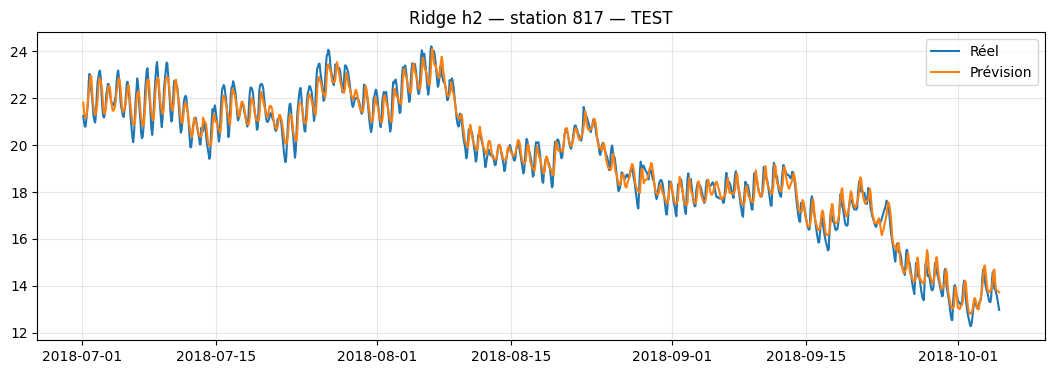

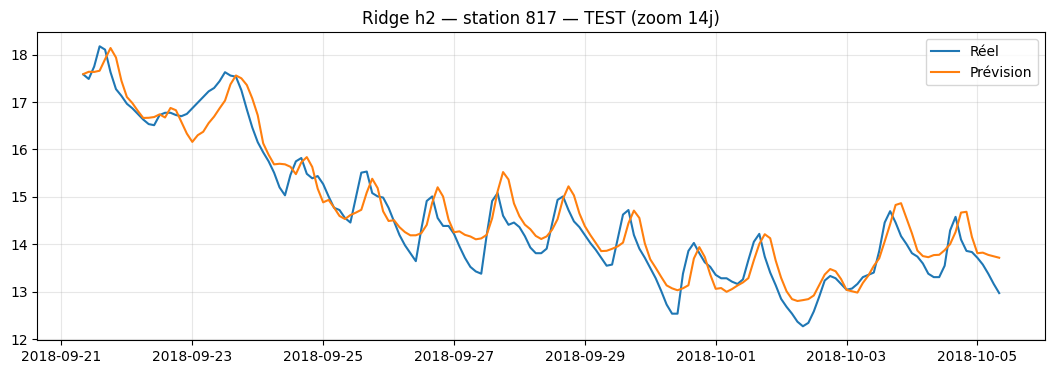

In [26]:
station_fig = 817

plot_test_forecast(
    preds_test_h2_ridge[preds_test_h2_ridge[ID_COL] == station_fig],
    title=f"Ridge h2 — station {station_fig} — TEST",
    zoom_days=14,
    save_dir=FIG_DIR,
    save_stem=f"test_ridge_h2_station_{station_fig}"
)


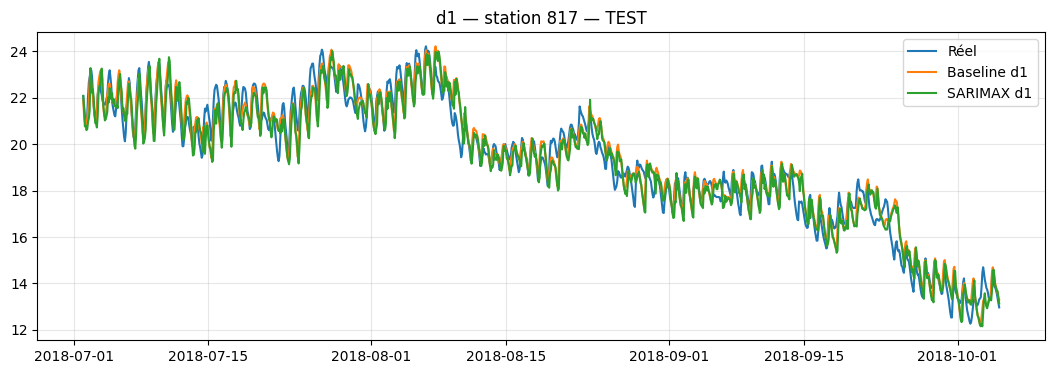

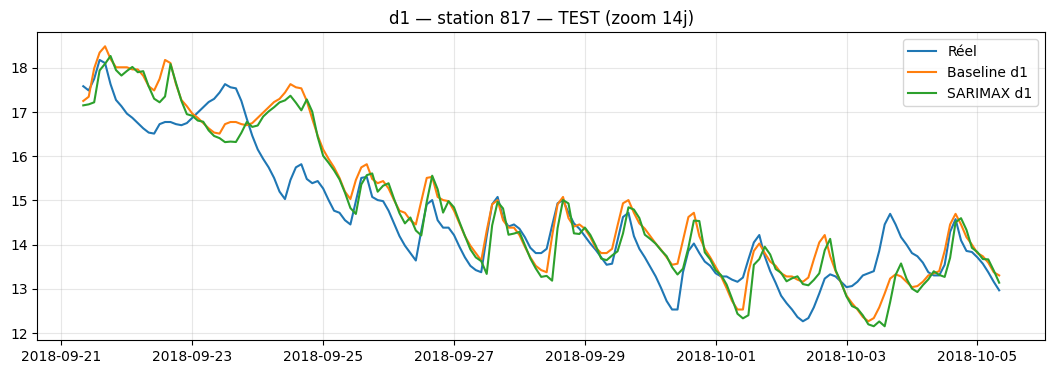

In [27]:
plot_compare_d1(
    preds_test_d1_base,
    preds_test_d1_smx,
    station_id=station_fig,
    id_col=ID_COL,
    zoom_days=14,
    save_dir=FIG_DIR,
    save_stem=f"test_compare_d1_station_{station_fig}"
)


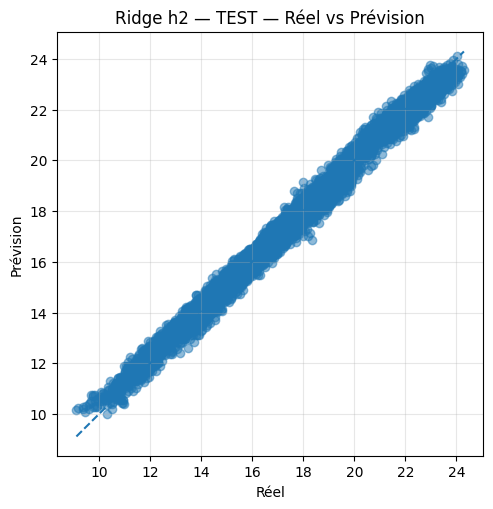

In [28]:

plot_scatter_true_pred(
    preds_test_h2_ridge,
    title="Ridge h2 — TEST — Réel vs Prévision",
    save_dir=FIG_DIR,
    save_name="test_scatter_ridge_h2.png"
)

### Figures finales sur TEST

Les figures finales confirment les résultats numériques obtenus sur le hold-out TEST.

### Ridge à l’horizon h2
Les courbes **réel vs prévision** montrent que Ridge suit correctement :
- la tendance globale,
- les fluctuations locales,
- et une grande partie de la variabilité court terme.

Le nuage de points `réel vs prévision` présente un alignement très proche de la diagonale, ce qui confirme la bonne qualité prédictive du modèle à l’horizon **h2**.

### Horizon d1 : baseline vs SARIMAX
À l’horizon **d1**, la comparaison visuelle entre la **baseline saisonnière journalière** et le **SARIMAX tuné** montre des trajectoires très proches.  
Cependant, les métriques sur TEST restent en faveur de la **baseline**, qui conserve les meilleures performances globales.

Ces figures confirment donc le choix final :
- **Ridge** pour les prévisions à très court terme (**h2**),
- **Baseline saisonnière journalière** pour **d1**.

## Conclusion

Le protocole final respecte strictement le découpage temporel défini au début du projet :

- **TRAIN** : 2013-05-29 → 2017-12-31
- **VAL** : 2018-01-01 → 2018-06-30
- **TEST** : 2018-07-01 → 2018-10-05

Le tuning a été réalisé uniquement sur **train/val**, puis les modèles retenus ont été évalués une seule fois sur **TEST**.

Les résultats finaux montrent que :

- **Ridge** est le meilleur modèle pour l’horizon **h2**,
- la **baseline saisonnière journalière** reste la meilleure approche pour **d1**,
- le **SARIMAX** constitue une alternative explicative intéressante, mais n’apporte pas de gain de performance sur TEST à l’horizon d1.

Le projet met ainsi en évidence qu’un modèle plus complexe n’est pas nécessairement supérieur à une baseline simple, selon l’horizon de prévision considéré.

In [30]:
# =========================================
# SAVE ALL TABLES / METRICS / PREDS / TUNING
# =========================================


with open(ART_07_SUM / "selected_models_final.json", "w", encoding="utf-8") as f:
    json.dump(selected_final, f, ensure_ascii=False, indent=2)

# ---------- tuning ----------
tune_ridge_h2.to_csv(ART_07_TBL / "tuning_ridge_h2_grid.csv", index=False)
tune_smx_fast_d1.to_csv(ART_07_TBL / "tuning_sarimax_d1_fast_screening.csv", index=False)
tune_smx_top_d1.to_csv(ART_07_TBL / "tuning_sarimax_d1_top2_full.csv", index=False)

# ---------- métriques globales séparées ----------
test_h2_ridge_global.to_csv(ART_07_MET / "final_test_metrics_h2_ridge_global.csv", index=False)
test_d1_base_global.to_csv(ART_07_MET / "final_test_metrics_d1_baseline_global.csv", index=False)
test_d1_smx_global.to_csv(ART_07_MET / "final_test_metrics_d1_sarimax_global.csv", index=False)

# ---------- métriques par station ----------
test_h2_ridge_station.to_csv(ART_07_MET / "final_test_metrics_h2_ridge_by_station.csv", index=False)
test_d1_base_station.to_csv(ART_07_MET / "final_test_metrics_d1_baseline_by_station.csv", index=False)
test_d1_smx_station.to_csv(ART_07_MET / "final_test_metrics_d1_sarimax_by_station.csv", index=False)

# ---------- comparaison finale ----------
final_test_cmp.to_csv(ART_07_MET / "final_test_metrics_global.csv", index=False)

# ---------- prédictions TEST ----------
preds_test_h2_ridge.to_csv(ART_07_PRD / "preds_test_h2_ridge.csv", index=False)
preds_test_d1_base.to_csv(ART_07_PRD / "preds_test_d1_baseline_daily.csv", index=False)
preds_test_d1_smx.to_csv(ART_07_PRD / "preds_test_d1_sarimax_tuned.csv", index=False)

# ---------- prédictions VAL tuning ----------
preds_ridge_best.to_csv(ART_07_PRD / "ridge_val_preds_best_alpha.csv", index=False)
tune_smx_top_d1.to_csv(ART_07_PRD / "sarimax_val_preds_best_cfg.csv", index=False)

print(" Saved selection :", ART_07_SUM)
print(" Saved tuning    :", ART_07_TBL)
print(" Saved metrics   :", ART_07_MET)
print(" Saved preds     :", ART_07_PRD)

 Saved selection : C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\summary
 Saved tuning    : C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\tables
 Saved metrics   : C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\metrics
 Saved preds     : C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\07_tuning_test\predictions
